# Laboratório 7B: Sarsa (CliffWalking)

## Importações

In [1]:
# Instala os pacotes necessários:
# - gymnasium[toy-text]: inclui ambientes simples como FrozenLake, Taxi, etc.
# - imageio[ffmpeg]: permite salvar vídeos e GIFs (formato .mp4 ou .gif)
!pip install gymnasium[toy-text] imageio[ffmpeg]

In [2]:
import gymnasium as gym
import imageio
from IPython.display import Image
import numpy as np
from typing import Dict, Tuple, List, Union, Optional, Set
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.collections import LineCollection
import seaborn as sns
import pandas as pd
from tqdm.auto import tqdm

## Funções auxiliares para visualização

In [3]:
def plotar_metricas(episodio_len: list[int], episodio_return: list[float], janela: int = 100) -> None:
    """
    Usa Pandas + Seaborn para plotar tamanho do episódio e retorno com média móvel.
    """

    df = pd.DataFrame({
        'episodio': np.arange(len(episodio_len)),
        'tamanho': episodio_len,
        'retorno': episodio_return
    })

    df['tamanho_ma'] = df['tamanho'].rolling(window=janela).mean()
    df['retorno_ma'] = df['retorno'].rolling(window=janela).mean()

    fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(12, 8), sharex=True)

    # Plot 1 – Tamanho do episódio
    sns.lineplot(data=df, x='episodio', y='tamanho', ax=axs[0], label='Tamanho do Episódio', alpha=0.3)
    sns.lineplot(data=df, x='episodio', y='tamanho_ma', ax=axs[0], label=f'Média móvel ({janela})')
    axs[0].set_ylabel('Passos por Episódio')
    axs[0].legend()
    axs[0].grid()

    # Plot 2 – Retorno
    sns.lineplot(data=df, x='episodio', y='retorno', ax=axs[1], label='Retorno do Episódio', color='orange', alpha=0.3)
    sns.lineplot(data=df, x='episodio', y='retorno_ma', ax=axs[1], label=f'Média móvel ({janela})', color='red')
    axs[1].set_xlabel('Episódio')
    axs[1].set_ylabel('Recompensa Total')
    axs[1].legend()
    axs[1].grid()

    plt.tight_layout()
    plt.show()

In [4]:
def visualizar_politica(
    Pi: np.ndarray,
    env_name: str,
    *,
    action_labels: Optional[List[str]] = None,
    destacar_gulosa: bool = True,
    suptitle: Optional[str] = "Política (distribuições por estado)",
    **env_kwargs,
) -> None:
    """
    Visualiza a política como barras por estado.

    Parâmetros
    ----------
    Pi : np.ndarray, shape (n_estados, n_acoes)
        Política estocástica (cada linha soma ≈ 1).
    env_name : {"FrozenLake-v1","CliffWalking-v1"}
        Nome do ambiente Gymnasium.
    action_labels : list[str] | None
        Rótulos das ações. Se None, usa o mapeamento correto de cada ambiente.
    destacar_gulosa : bool
        Se True, escurece a barra da ação de maior probabilidade em cada estado.
    suptitle : str | None
        Título superior da figura.
    **env_kwargs :
        Parâmetros repassados ao gym.make (ex.: map_name="4x4", is_slippery=False).
    """

    n_estados, n_acoes = Pi.shape

    env = gym.make(env_name, **env_kwargs)

    try:
        # --------- Grid e terminais ---------
        if env_name == "FrozenLake-v1":
            desc = env.unwrapped.desc
            desc_str = np.char.decode(desc, "utf-8") if getattr(desc.dtype, "kind", "") == "S" else desc.astype(str)
            n_rows, n_cols = desc_str.shape
            holes = (desc_str == "H")
            goal  = (desc_str == "G")
            default_labels = ["←", "↓", "→", "↑"]   # 0:left,1:down,2:right,3:up

        elif env_name == "CliffWalking-v1":
            n_rows, n_cols = env.unwrapped.shape
            holes = np.zeros((n_rows, n_cols), dtype=bool)
            holes[n_rows - 1, 1:n_cols - 1] = True  # falésia
            goal = np.zeros((n_rows, n_cols), dtype=bool)
            goal[n_rows - 1, n_cols - 1] = True     # alvo
            default_labels = ["↑", "→", "↓", "←"]   # 0:up,1:right,2:down,3:left

        else:
            raise ValueError("env_name deve ser 'FrozenLake-v1' ou 'CliffWalking-v1'.")

        if n_rows * n_cols != n_estados:
            raise ValueError(f"Incompatibilidade: grid {n_rows}x{n_cols} != n_estados={n_estados} em Pi.")

        # --------- Rótulos das ações ---------
        if action_labels is None:
            if n_acoes == 4:
                action_labels = default_labels
            else:
                action_labels = [f"a{i}" for i in range(n_acoes)]
        elif len(action_labels) != n_acoes:
            action_labels = [f"a{i}" for i in range(n_acoes)]

        # --------- Figura ---------
        fig, axs = plt.subplots(n_rows, n_cols, figsize=(3.0 * n_cols, 2.2 * n_rows))
        axs = np.array(axs).reshape(-1)

        for s in range(n_estados):
            r, c = divmod(s, n_cols)
            ax = axs[s]

            # Estados terminais (sem barras)
            if holes[r, c]:
                # vermelho translúcido
                ax.set_facecolor((1.0, 0.0, 0.0, 0.18))
                ax.set_title(f"Estado {s} ({'H' if env_name=='FrozenLake-v1' else 'penhasco'})")
                ax.set_xticks([]); ax.set_yticks([])
                for sp in ax.spines.values(): sp.set_visible(True)
                continue

            if goal[r, c]:
                # verde translúcido
                ax.set_facecolor((0.0, 1.0, 0.0, 0.18))
                ax.set_title(f"Estado {s} ({'G' if env_name=='FrozenLake-v1' else 'alvo'})")
                ax.set_xticks([]); ax.set_yticks([])
                for sp in ax.spines.values(): sp.set_visible(True)
                continue

            # Estado não-terminal: barras da distribuição
            pi = Pi[s].astype(float)
            if pi.sum() > 0:
                pi /= pi.sum()  # normalização defensiva

            acoes = np.arange(n_acoes)
            colors = ["gray"] * n_acoes
            if destacar_gulosa:
                colors[int(np.argmax(pi))] = "dimgray"

            ax.bar(acoes, pi, color=colors)
            ax.set_ylim(0, 1.05)
            ax.set_xticks(acoes)
            ax.set_xticklabels(action_labels)
            ax.set_yticks([0, 0.5, 1.0])
            ax.set_title(f"Estado {s}")

        for i in range(n_estados, len(axs)):
            fig.delaxes(axs[i])

        if suptitle:
            fig.suptitle(suptitle, y=1.02, fontsize=12)

        plt.tight_layout()
        plt.show()
    finally:
        env.close()

In [5]:
def plot_V_grid(
    V: np.ndarray,
    env_name: str,
    *,
    ax=None,
    cbar: bool = True,
    fmt: str = ".1f",
    center_zero: bool = False,
    title: str | None = None,
):
    """
    Plota V(s) em formato de grid, com reshape automático para ambientes discretos padrão.

    Regras:
      - Se V for 2D: plota diretamente (caso 'Labirinto' ou outro ambiente customizado).
      - Se env_name == 'CliffWalking-v1': reshape para (4, 12).
      - Se env_name == 'FrozenLake-v1': infere lado = sqrt(n_estados) → (lado, lado).

    Parâmetros
    ----------
    V : np.ndarray
        Vetor 1D (n_estados,) ou matriz 2D (n_rows, n_cols) de valores de estado.
    env_name : str
        Nome do ambiente ('FrozenLake-v1', 'CliffWalking-v1' ou outro).
    """
    # Inferir formato
    if V.ndim == 2:
        M = V
    else:
        if env_name == "CliffWalking-v1":
            M = V.reshape(4, 12)
        elif env_name == "FrozenLake-v1":
            n = V.shape[0]
            side = int(np.sqrt(n))
            if side * side != n:
                raise ValueError(f"FrozenLake: n_estados={n} não forma um grid quadrado.")
            M = V.reshape(side, side)
        else:
            raise ValueError(
                f"Para env_name='{env_name}', V deve ser passado já como array 2D."
            )

    # Preparar figura
    if ax is None:
        fig, ax = plt.subplots(figsize=(M.shape[1], M.shape[0]))
    else:
        fig = None

    if center_zero:
        vmax = float(np.abs(M).max())
        vmin = -vmax
    else:
        vmin = float(M.min())
        vmax = float(M.max())

    # Plotar heatmap
    sns.heatmap(
        M, annot=True, fmt=fmt, cmap="bwr",
        vmin=vmin, vmax=vmax, cbar=cbar, square=True,
        linewidths=0.5, linecolor="gray", ax=ax
    )

    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlabel("Colunas"); ax.set_ylabel("Linhas")
    ax.set_title(title if title else f"V(s) — {env_name}")

    for side in ("left", "right", "top", "bottom"):
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(0.5)
        ax.spines[side].set_edgecolor("gray")

    if fig is not None:
        plt.tight_layout()
        plt.show()

    return ax

def plot_tabular(
    data: np.ndarray,
    kind: str = "Q",                 # "Q", "Pi" ou "V"
    env_name: str | None = None,     # necessário quando kind="V"
    ax=None,
    cbar: bool = True,
    fmt: str = ".1f",
    center_zero: bool = True,        # só relevante para "Q" e "V"
    title: str | None = None,
):
    """
    Plota matrizes tabulares de RL:
      - kind="Q": heatmap de Q(s,a) (ações nas linhas, estados nas colunas).
      - kind="Pi": heatmap de π(a|s) (probabilidades) (ações nas linhas, estados nas colunas).
      - kind="V": usa plot_V_grid para reorganizar e plotar V(s) no grid conforme env_name.

    Para kind="V":
      - env_name == "CliffWalking-v1": reshape automático para (4,12).
      - env_name == "FrozenLake-v1": inferência automática do lado (√n_estados).
      - qualquer outro env_name: espera V já 2D.
    """
    kind = kind.upper()

    if kind == "V":
        if env_name is None:
            raise ValueError("Para kind='V', passe env_name ('FrozenLake-v1', 'CliffWalking-v1' ou outro).")
        # delega ao plot_V_grid
        return plot_V_grid(
            V=data,
            env_name=env_name,
            ax=ax,
            cbar=cbar,
            fmt=fmt,
            center_zero=center_zero,
            title=title if title else f"V(s) — {env_name}",
        )

    # casos Q e Pi
    xlabel = {"PI": "Estados", "Q": "Estados"}
    ylabel = {"PI": "Ações",  "Q": "Ações"}
    default_title = {"PI": r"Política ($\pi(a|s)$) transposta", "Q": "Valores de ação (Q) transposta"}

    # Q(s,a) e Pi(a|s): ações nas linhas, estados nas colunas
    M = data.T  # (n_estados, n_acoes) -> (n_acoes, n_estados)
    n_acoes, n_estados = M.shape

    if ax is None:
        fig, ax = plt.subplots(figsize=(n_estados, n_acoes))
    else:
        fig = None

    if kind == "PI":
        cmap = "Blues"; vmin, vmax = 0.0, 1.0
    elif kind == "Q":
        cmap = "bwr"
        if center_zero:
            vmax = float(np.abs(M).max()); vmin = -vmax
        else:
            vmin = float(M.min()); vmax = float(M.max())
    else:
        raise ValueError(f"kind desconhecido: {kind!r} (use 'Q', 'Pi' ou 'V').")

    ax = sns.heatmap(
        data=M,
        annot=True,
        fmt=fmt,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        cbar=cbar,
        square=False,
        linewidths=0.5,
        linecolor="gray",
        ax=ax
    )

    ax.set_xlabel(xlabel[kind])
    ax.set_ylabel(ylabel[kind])
    ax.set_title(title if title else default_title[kind])

    # bordas e rótulos
    for side in ("left", "right", "top", "bottom"):
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(0.5)
        ax.spines[side].set_edgecolor("gray")

    ax.set_xticks(np.arange(n_estados) + 0.5)
    ax.set_xticklabels([f"s{i}" for i in range(n_estados)], rotation=0)
    ax.set_yticks(np.arange(n_acoes) + 0.5)
    ax.set_yticklabels([f"a{i}" for i in range(n_acoes)], rotation=0)

    if fig is not None:
        plt.tight_layout()
        plt.show()

    return ax

In [6]:
# helpers de grid/máscaras
def _grid_info_from_env(env_name: str, map_name: str | None = None, is_slippery: bool = False):
    """
    Retorna (n_rows, n_cols, holes_set, cliffs_set, goals_set, start_rc)
    para FrozenLake-v1 ou CliffWalking-v1.
    """
    holes, cliffs, goals = set(), set(), set()
    start_rc = None

    if env_name == "FrozenLake-v1":
        kwargs = {}
        if map_name is not None:
            kwargs["map_name"] = map_name
        kwargs["is_slippery"] = is_slippery

        env = gym.make("FrozenLake-v1", **kwargs)
        desc = env.unwrapped.desc
        # decode se dtype for bytes
        desc = np.array(desc, dtype=str) if desc.dtype.kind != "S" else np.char.decode(desc, "utf-8")
        n_rows, n_cols = desc.shape
        for r in range(n_rows):
            for c in range(n_cols):
                ch = desc[r, c]
                if ch == "H": holes.add((r, c))
                elif ch == "G": goals.add((r, c))
                elif ch == "S": start_rc = (r, c)
        if start_rc is None:
            start_rc = (0, 0)
        env.close()
        return n_rows, n_cols, holes, cliffs, goals, start_rc

    elif env_name == "CliffWalking-v1":
        n_rows, n_cols = 4, 12
        start_rc = (n_rows - 1, 0)
        goal_rc  = (n_rows - 1, n_cols - 1)
        goals.add(goal_rc)
        # penhasco: última linha, colunas 1..10
        for c in range(1, n_cols - 1):
            cliffs.add((n_rows - 1, c))
        return n_rows, n_cols, holes, cliffs, goals, start_rc

    else:
        raise ValueError("env_name deve ser 'FrozenLake-v1' ou 'CliffWalking-v1'.")


def _rc_from_state(s: int, n_cols: int) -> tuple[int, int]:
    return divmod(s, n_cols)  # (r,c)


# simulação de trajetória
def simular_trajetoria_gym(
    Pi: np.ndarray,
    env_name: str,
    *,
    map_name: str | None = None,
    is_slippery: bool = False,
    max_steps: int = 200
):
    """
    Executa uma trajetória determinística (gulosa em Pi) no Gym (FrozenLake/CliffWalking).
    Retorna:
      - estados: lista de (r,c)
      - acoes: lista de ints
      - recompensas: lista de floats
    """
    # cria env
    if env_name == "FrozenLake-v1":
        kwargs = {}
        if map_name is not None:
            kwargs["map_name"] = map_name
        kwargs["is_slippery"] = is_slippery
        env = gym.make("FrozenLake-v1", **kwargs)
    elif env_name == "CliffWalking-v1":
        env = gym.make("CliffWalking-v1")
    else:
        raise ValueError("env_name deve ser 'FrozenLake-v1' ou 'CliffWalking-v1'.")

    n_rows, n_cols, holes, cliffs, goals, start_rc = _grid_info_from_env(env_name, map_name, is_slippery)

    # sanity check de dimensões
    n_states, n_actions = Pi.shape
    assert n_states == n_rows * n_cols, f"Pi.shape[0]={n_states} != n_rows*n_cols={n_rows*n_cols}"
    assert n_actions == env.action_space.n, f"Pi.shape[1]={n_actions} != action_space.n={env.action_space.n}"

    state, _ = env.reset()
    # se o env permitir setar estado diretamente, tenta (FrozenLake/cliff costumam expor .unwrapped.s)
    if hasattr(env.unwrapped, "s"):
        env.unwrapped.s = int(state)

    estados_rc = [_rc_from_state(int(state), n_cols)]
    acoes, recompensas = [], []

    for _ in range(max_steps):
        s = int(state)
        a = int(np.argmax(Pi[s]))
        next_state, reward, terminated, truncated, _ = env.step(a)

        acoes.append(a)
        recompensas.append(float(reward))
        estados_rc.append(_rc_from_state(int(next_state), n_cols))

        state = next_state
        if terminated or truncated:
            break

    env.close()
    return estados_rc, acoes, recompensas


# --------------------------
# plot da trajetória no grid
# --------------------------
def plot_trajetoria_gym(
    env_name: str,
    estados: list[tuple[int, int]],
    *,
    map_name: str | None = None,
    is_slippery: bool = False,
    titulo: str = "Trajetória gulosa (Gym)",
    gradiente_temporal: bool = True,
    mostrar_setas: bool = True
):
    """
    Plota a trajetória sobre um grid para FrozenLake/CliffWalking com destaques de buracos/penhasco/goal.
    """
    n_rows, n_cols, holes, cliffs, goals, start_rc = _grid_info_from_env(env_name, map_name, is_slippery)

    # figura/base do grid
    fig, ax = plt.subplots(figsize=(n_cols, n_rows))
    ax.set_xlim(0, n_cols); ax.set_ylim(0, n_rows)
    ax.set_xticks(np.arange(0, n_cols + 1, 1))
    ax.set_yticks(np.arange(0, n_rows + 1, 1))
    ax.grid(True); ax.set_aspect('equal'); ax.invert_yaxis()

    # células coloridas
    for r in range(n_rows):
        for c in range(n_cols):
            cell = (r, c)
            if env_name == "FrozenLake-v1":
                if cell in holes:
                    color = (1.0, 0.0, 0.0, 0.25)  # vermelho translúcido
                elif cell in goals:
                    color = (0.0, 1.0, 0.0, 0.25)  # verde translúcido
                elif cell == start_rc:
                    color = (1.0, 1.0, 0.0, 0.18)  # amarelo leve
                else:
                    color = 'white'
            else:  # CliffWalking
                if cell in cliffs:
                    color = (1.0, 0.0, 0.0, 0.25)
                elif cell in goals:
                    color = (0.0, 1.0, 0.0, 0.25)
                elif cell == start_rc:
                    color = (1.0, 1.0, 0.0, 0.18)
                else:
                    color = 'white'

            rect = patches.Rectangle((c, r), 1, 1, facecolor=color, edgecolor='gray')
            ax.add_patch(rect)

    # extrai xs, ys (centros)
    xs = [c + 0.5 for (_, c) in estados]
    ys = [r + 0.5 for (r, _) in estados]

    # linha com gradiente temporal
    if gradiente_temporal and len(xs) > 1:
        pontos = np.array([xs, ys]).T
        segmentos = np.stack([pontos[:-1], pontos[1:]], axis=1)
        lc = LineCollection(segmentos, linewidths=2.5)
        cores = np.linspace(0, 1, len(segmentos))
        lc.set_array(cores)
        ax.add_collection(lc)
        cbar = plt.colorbar(lc, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label("Progresso temporal")
    else:
        ax.plot(xs, ys, '-o', linewidth=2.5, markersize=4)

    # início/fim
    ax.scatter(xs[0], ys[0], marker='*', s=220, edgecolor='black', facecolor='yellow', zorder=5, linewidths=1.2, label='Início')
    ax.scatter(xs[-1], ys[-1], marker='o', s=150, edgecolor='black', facecolor='none', zorder=5, linewidths=1.2, label='Fim')

    # setas entre células
    if mostrar_setas:
        for i in range(len(xs) - 1):
            dx, dy = xs[i+1] - xs[i], ys[i+1] - ys[i]
            ax.arrow(xs[i], ys[i], dx*0.85, dy*0.85, head_width=0.15, head_length=0.15,
                     length_includes_head=True, fc='black', ec='black', alpha=0.8)

    ax.set_title(titulo)
    ax.legend(loc='upper right', frameon=True)
    plt.tight_layout()
    plt.show()

In [7]:
def gerar_gif_simulacao(
    Pi: np.ndarray,
    env,
    path_gif: str,
    n_episodios: int = 5,
    max_steps: int = 200,
    fps: int = 2,
    greedy: bool = False,
    normalizar: bool = True,
) -> str:
    """
    Simula episódios com a política Pi (array numpy) e gera um GIF.

    Parâmetros
    ----------
    Pi : np.ndarray, shape (n_estados, n_acoes)
        Política estocástica por estado. Se `greedy=False`, amostra ações segundo Pi[s].
        Se `greedy=True`, escolhe argmax_a Pi[s, a].
    env : gymnasium.Env
        Ambiente Gymnasium com `render_mode='rgb_array'`.
   path_gif : str
        Caminho/arquivo de saída do GIF (ex.: "execucao.gif").
    n_episodios : int, default=5
        Quantidade de episódios simulados no GIF.
    max_steps : int, default=200
        Máximo de passos por episódio.
    fps : int, default=2
        Frames por segundo do GIF.
    greedy : bool, default=False
        Se True, usa ação gulosa (argmax). Se False, amostra segundo Pi[s].
    normalizar : bool, default=True
        Se True, normaliza Pi[s] para somar 1 quando for amostrar.

    Retorna
    -------
    str
        Caminho do GIF gerado.
    """
    # Verificações rápidas para espaços discretos
    assert hasattr(env.observation_space, "n") and hasattr(env.action_space, "n"), \
        "Este utilitário espera espaços Discrete (ex.: FrozenLake, CliffWalking)."
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    if Pi.shape != (n_states, n_actions):
        raise ValueError(f"Shape incompatível: Pi{Pi.shape} != ({n_states}, {n_actions})")

    frames = []

    for _ in range(n_episodios):
        state, _ = env.reset()

        # captura frame inicial do episódio
        frame = env.render()
        if frame is not None:
            frames.append(frame)

        for _ in range(max_steps):
            if greedy:
                action = int(np.argmax(Pi[state]))
            else:
                probs = Pi[state].astype(float)
                if normalizar:
                    s = probs.sum()
                    if s > 0:
                        probs = probs / s
                # fallback se a linha for toda zero (ou numérica inválida)
                if not np.isfinite(probs).all() or probs.sum() <= 0:
                    probs = np.full(n_actions, 1.0 / n_actions)
                action = int(np.random.choice(n_actions, p=probs))

            state, reward, terminated, truncated, _ = env.step(action)

            frame = env.render()
            if frame is not None:
                frames.append(frame)

            if terminated or truncated:
                break

    env.close()
    imageio.mimsave(path_gif, frames, format="GIF", fps=fps)
    return path_gif

## Ambiente: nova instância

In [8]:
# Configura o ambiente
ambiente = 'CliffWalking-v1'
render_mode = 'rgb_array'  # retorna imagens do ambiente como arrays de pixels
env = gym.make(ambiente, render_mode=render_mode)

## Algoritmo: Sarsa

In [9]:
# def sarsa(
#     env,
#     gamma: float = 0.9,
#     N: int = 500,               # episódios
#     epsilon: float = 0.1,
#     alpha: float = 0.1,
#     seed: Optional[int] = None
# ) -> Tuple[np.ndarray, np.ndarray, np.ndarray, int, List[int], List[float]]:
#     """
#     SARSA(0) on-policy com política ε-gulosa (ε-suave) para ambientes Gymnasium de espaço discreto.

#     Parâmetros
#     ----------
#     env : gymnasium.Env
#         Ambiente com observation_space/action_space do tipo Discrete.
#     gamma : float
#         Fator de desconto.
#     N : int
#         Número de episódios.
#     eps : float
#         Parâmetro ε da política ε-gulosa (0 ≤ ε ≤ 1).
#     alpha : float
#         Taxa de aprendizado.
#     seed : int | None
#         Semente de aleatoriedade (usada para `np.random.default_rng` e opcionalmente em `env.reset`).

#     Retorna
#     -------
#     Q   : np.ndarray, shape (n_states, n_actions)
#         Estimativas finais Q(s,a).
#     Pi  : np.ndarray, shape (n_states, n_actions)
#         Política ε-suave resultante.
#     numero_de_visitas : np.ndarray, shape (n_states, n_actions)
#         Contagem de visitas por par (s,a).
#     k   : int
#         Número de episódios efetivamente executados (== N).
#     episodio_T : list[int]
#         Comprimento (passos) de cada episódio.
#     episodio_G : list[float]
#         Retorno (soma de recompensas não-descontadas) de cada episódio.
#     """

#     # Atalhos
#     n_states  = env.observation_space.n
#     n_actions = env.action_space.n

#     rng = np.random.default_rng(seed)

#     # Tabelas
#     Q                 = np.zeros((n_states, n_actions), dtype=float)
#     Pi                = np.full((n_states, n_actions), 1.0 / n_actions, dtype=float)
#     numero_de_visitas = np.zeros((n_states, n_actions), dtype=float)

#     episodio_T = []
#     episodio_G = []

#     for k in tqdm(range(1, N + 1), desc="Episódios (SARSA)", leave=True):
#         # Reset para o estado inicial (s0)
#         s, _ = env.reset()


#         ############################################################################
#         # Implementação aqui
#         # Dica:
#         # usar
#         # próximo estado, recompensa, terminated (flag), truncated (flag), _ = env.step(ação)
#         # para fazer a trasição de um estado para o outro dada uma ação do agente




#         ############################################################################

#     return Q, Pi, numero_de_visitas, N, episodio_T, episodio_G

Minha resolução:

In [10]:
def sarsa(
    env,
    gamma: float = 0.9,
    N: int = 500,               # episódios
    epsilon: float = 0.1,
    alpha: float = 0.1,
    seed: Optional[int] = None
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, int, List[int], List[float]]:
    """
    SARSA(0) on-policy com política ε-gulosa (ε-suave) para ambientes Gymnasium de espaço discreto.
    (Implementação baseada no Lab 7A)
    """

    # --- Funções auxiliares (copiadas do Lab 7A) ---
    def _atualiza_Q(Q, experiencia, alpha, gamma):
        s, a, r, s_next, a_next = experiencia
        td_target = r + gamma * Q[s_next, a_next]
        td_error  = Q[s, a] - td_target
        Q[s, a]  -= alpha * td_error

    def _atualiza_Pi(Pi: np.ndarray, Q: np.ndarray, s: int, eps: float) -> None:
        """
        Deixa Pi[s, :] ε-suave em torno de argmax_a Q[s, a].
        """
        n_acoes = Q.shape[1]
        a_star = int(np.argmax(Q[s]))
        Pi[s, :] = eps / n_acoes
        Pi[s, a_star] += 1.0 - eps
    # --- Fim das funções auxiliares ---


    # Atalhos
    n_states  = env.observation_space.n
    n_actions = env.action_space.n

    rng = np.random.default_rng(seed)

    # Tabelas
    Q                 = np.zeros((n_states, n_actions), dtype=float)
    # Política inicial ε-suave: uniforme (como em 7A)
    Pi                = np.full((n_states, n_actions), 1.0 / n_actions, dtype=float)
    numero_de_visitas = np.zeros((n_states, n_actions), dtype=float)

    episodio_T = []
    episodio_G = []

    for k in tqdm(range(1, N + 1), desc="Episódios (SARSA)", leave=True):
        # Reset para o estado inicial (s0) - API do Gymnasium
        # (Opcionalmente, poderíamos usar env.reset(seed=seed) para reprodutibilidade por episódio,
        # mas seguimos o padrão do 7A de semear apenas o rng).
        s, _ = env.reset()
        s = int(s) # Garantir que é índice

        # Escolhe ação a_0 ~ Pi(s_0) (lógica do 7A)
        a = int(rng.choice(n_actions, p=Pi[s]))

        # Acumuladores do episódio (lógica do 7A)
        G = 0.0
        t = 0

        terminated = False
        truncated = False

        # Loop de passos (adaptado do 7A para a API do Gymnasium)
        while not terminated and not truncated:

            # Número de visitas ao par (s,a) (lógica do 7A)
            numero_de_visitas[s, a] += 1.0

            # Passo no ambiente (API do Gymnasium)
            s_next, r, terminated, truncated, _ = env.step(a)
            s_next = int(s_next) # Garantir que é índice

            # Incrementa acumuladores (lógica do 7A)
            G += r
            t += 1

            # Escolhe ação a_{t+1} ~ Pi(s_{t+1}) (lógica do 7A)
            a_next = int(rng.choice(n_actions, p=Pi[s_next]))

            # Dados (lógica do 7A)
            experiencia = (s, a, r, s_next, a_next)

            # Etapa da estimação de Q(s,a): (lógica do 7A)
            _atualiza_Q(Q, experiencia, alpha, gamma)

            # Etapa de melhoria de politica: (lógica do 7A)
            # (Usando 'epsilon' da assinatura da função 7B)
            _atualiza_Pi(Pi, Q, s, epsilon)

            # Avança (lógica do 7A)
            s, a = s_next, a_next

        # Registra métricas do episódio (lógica do 7A)
        episodio_T.append(t)
        episodio_G.append(G)

    return Q, Pi, numero_de_visitas, N, episodio_T, episodio_G

## Experimento

### Simulação

In [11]:
# Hiper-parâmetros principais
EPISODIOS = 5000  # @param {type:"integer"}  # número de episódios
ALPHA     = 0.01  # @param {type:"number"}
GAMMA     = 0.9   # @param {type:"number"}
EPSILON   = 0.3   # @param {type:"number"}
SEED      = 42    # @param {type:"integer"}

In [12]:
# Sarsa
Q, Pi, numero_de_visitas, k, T, G = sarsa(
    env,
    gamma=GAMMA,
    N=EPISODIOS,
    epsilon=EPSILON,
    alpha=ALPHA,
    seed=SEED
)

# Derivar V a partir de Q:
V = np.sum(Pi * Q, axis=1)

Episódios (SARSA):   0%|          | 0/5000 [00:00<?, ?it/s]

### Visualização

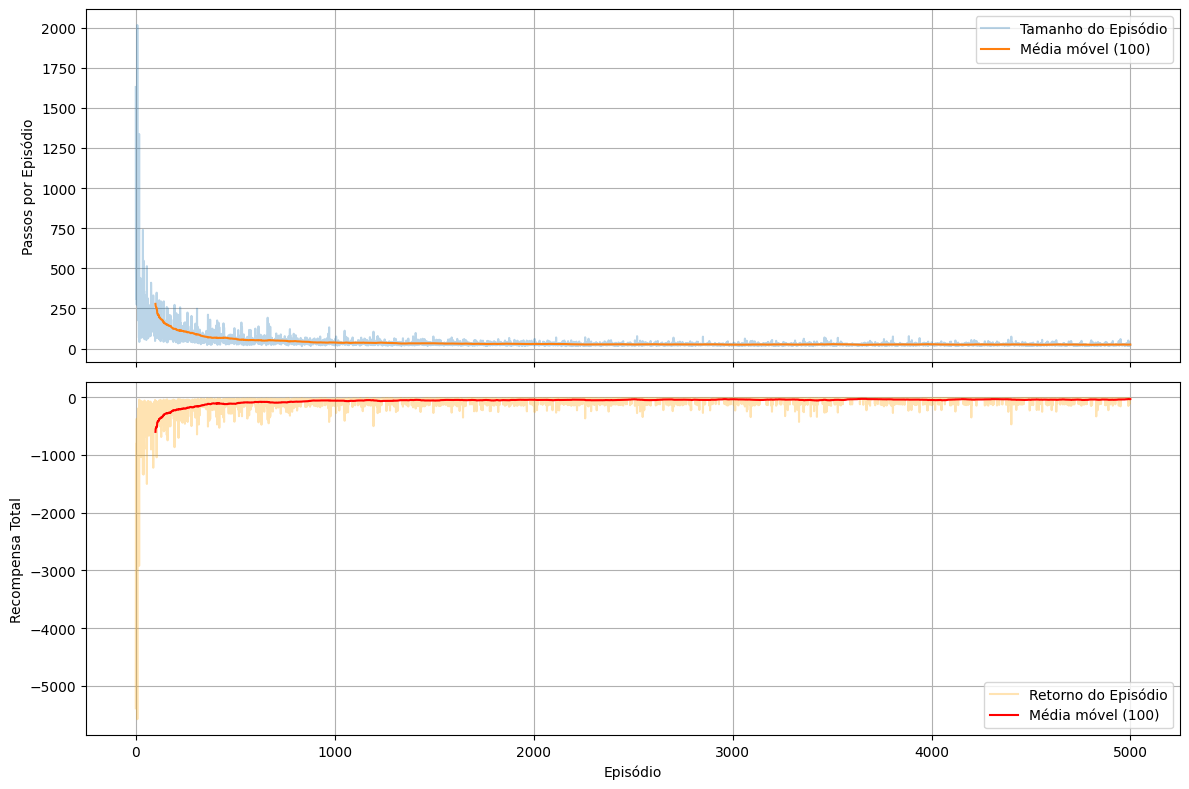

In [13]:
plotar_metricas(T, G)

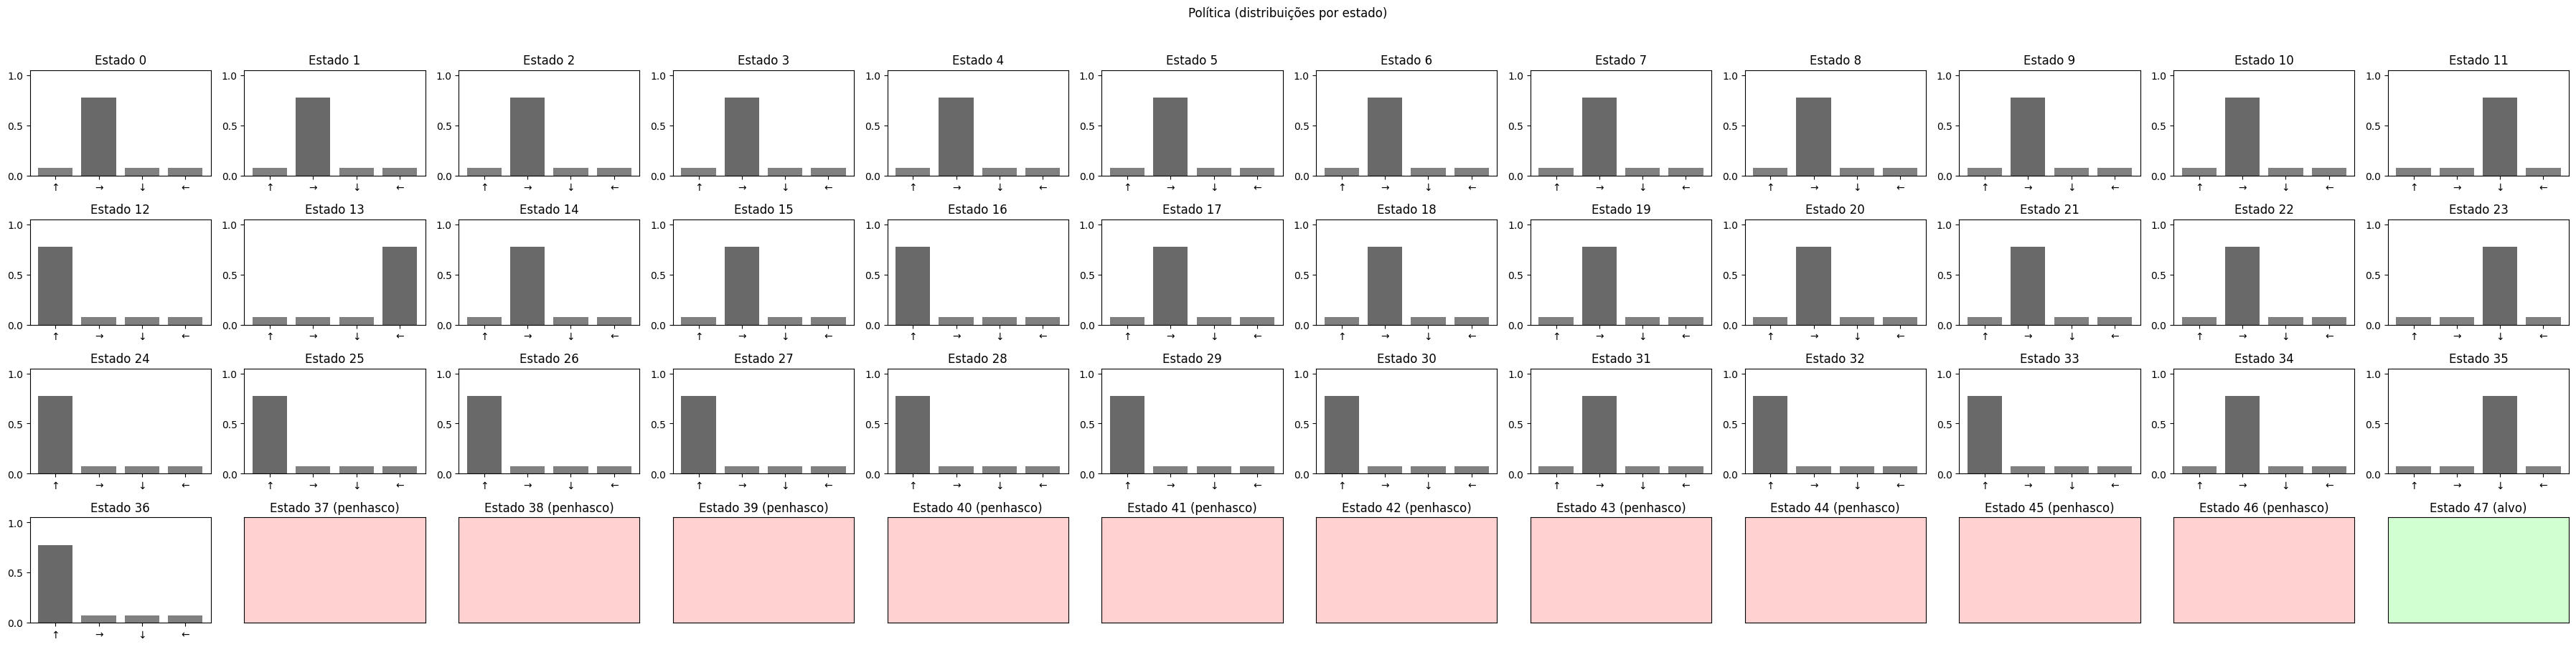

In [14]:
visualizar_politica(Pi, ambiente)

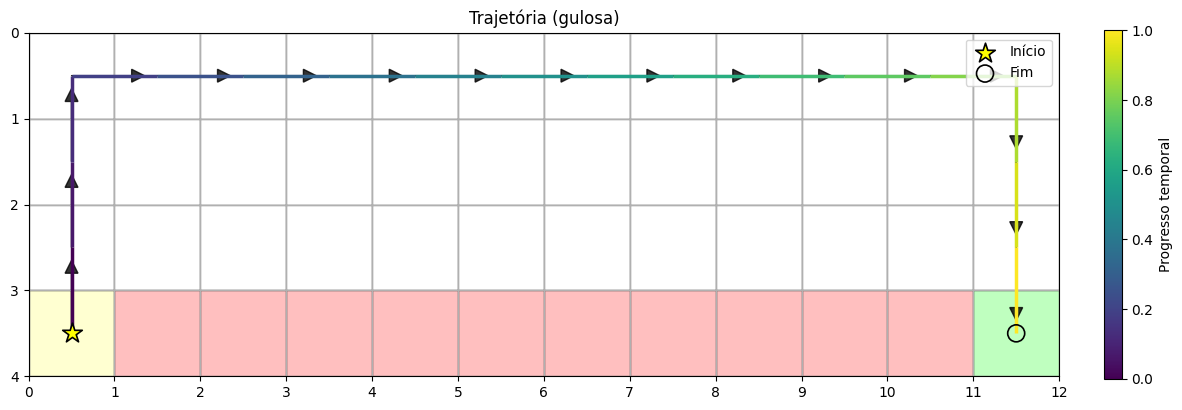

In [15]:
estados, acoes, recompensas = simular_trajetoria_gym(Pi, "CliffWalking-v1", max_steps=200)
plot_trajetoria_gym("CliffWalking-v1", estados, titulo="Trajetória (gulosa)")

In [16]:
# Recria ambiente para renderizar
env = gym.make(ambiente, render_mode="rgb_array")
path_gif="politica.gif"
gif = gerar_gif_simulacao(Pi, env, path_gif=path_gif, n_episodios=10, greedy=False)

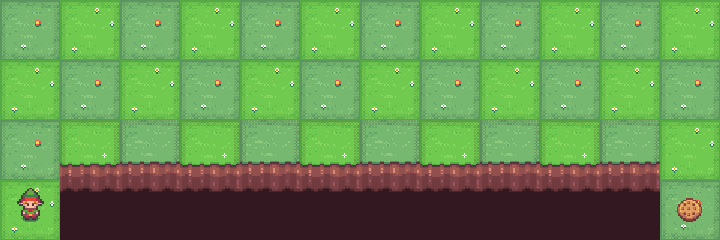

In [17]:
# Exibe o GIF diretamente no notebook
Image(filename=path_gif)

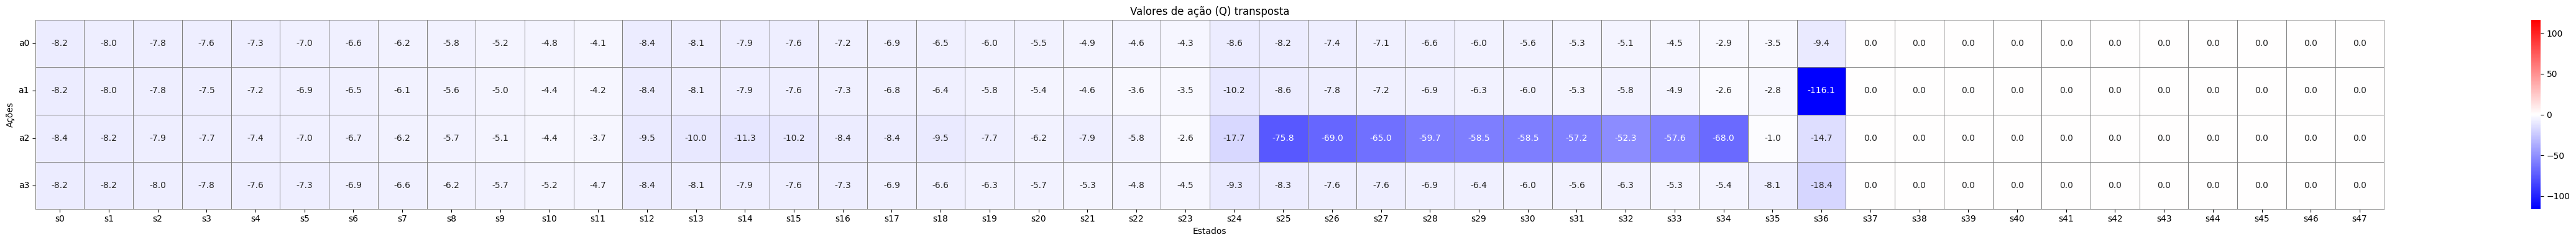

<Axes: title={'center': 'Valores de ação (Q) transposta'}, xlabel='Estados', ylabel='Ações'>

In [18]:
# Q: ndarray (n_estados, n_acoes)
plot_tabular(Q, kind="Q")

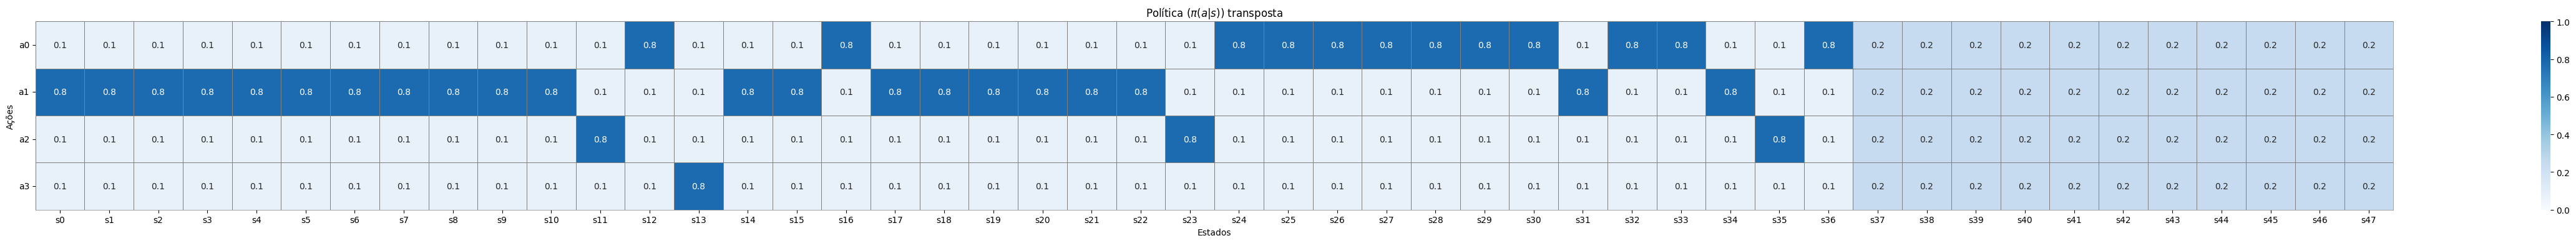

<Axes: title={'center': 'Política ($\\pi(a|s)$) transposta'}, xlabel='Estados', ylabel='Ações'>

In [19]:
# Pi: ndarray (n_estados, n_acoes)
plot_tabular(Pi, kind="Pi")

CliffWalking-v1


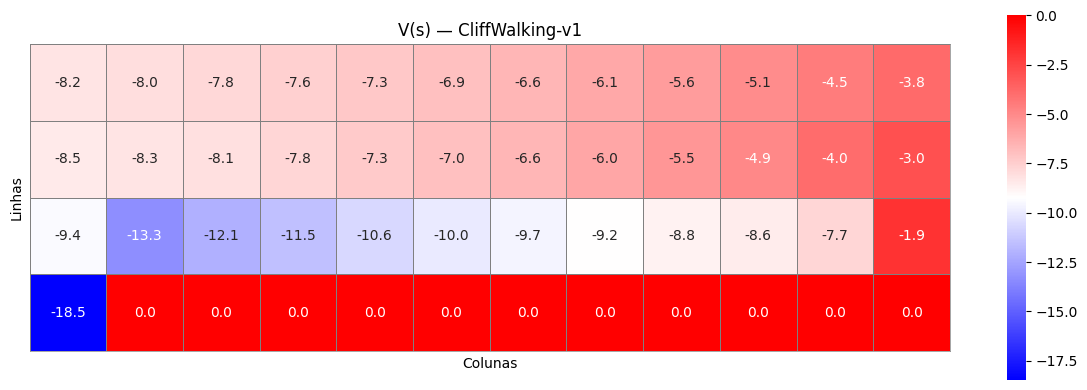

In [20]:
# V: ndarray (n_estados,)
print(ambiente)
_ = plot_tabular(V, kind="V", env_name=ambiente, center_zero=False)

# Tarefa:

1. Implemente o algoritmo Sarsa para resolver o ambiente `'CliffWalking-v1'` do [gymnasium](https://gymnasium.farama.org/environments/toy_text/cliff_walking/).
2. Considere os 4 hiperparametros (EPISODIOS, ALPHA, GAMMA, EPSILON)
    - Varie um dos hiperparametros (ex.: EPISODIOS) e fixe os demais (ex.: ALPHA, GAMMA, EPSILON).
        - Obs.: 3 valores para cada hiperparâmetro.
    - Para cada estudo de hiperparâmetro plote:
        - A duração do episódio por episódio
        - A recompensa total por episodio
        - Uma trajetória gulosa utilizando `plot_trajetoria_gym`.
    - Observação: as curvas para cada estudo de hiperparâmetro devem estar na mesma figura, isto é, se o hiperparâmetro a ser variado é o EPSILON com 3 valores, então o gráfico de duração do episódio deve mostrar as 3 curvas relativas a cada valor de EPSILON (com legenda) e de maneira similar para a recompensa total por episodio.
3. Repita o procedimento para cada um dos hiperparametros.
4. Reporte suas observações.

**Entregáveis:**

2. **Código** (notebook `*.ipynb`)
1. **Relatório** (`*.pdf`).
- O PDF deve conter:
  - **Setup** (hiperparâmetros usados).
  - **Resultados** (figuras e tabelas organizadas por experimento).
  - **Análises curtas** por experimento.
- O PDF **NÃO** deve conter:
    - Códigos.

### Funções auxiliares para tarefa:

In [21]:
def executar_variacao_hiperparametro(
    env,
    param_name: str,
    param_values: list,
    fixed_params: dict,
    seed: int
) -> Tuple[pd.DataFrame, pd.DataFrame, dict]:
    """
    Executa o SARSA variando um hiperparâmetro e mantendo os outros fixos.

    Retorna:
    - df_T_combined: DataFrame com os passos por episódio para todos os valores.
    - df_G_combined: DataFrame com os retornos por episódio para todos os valores.
    - all_Pi: Dicionário com as políticas finais para cada valor.
    """
    data_T = []
    data_G = []
    all_Pi = {}

    print(f"Variando o hiperparâmetro {param_name} com os valores: {param_values}")
    print(f"Parâmetros fixos: {fixed_params}")

    for value in param_values:
        print(f"\nExecutando SARSA com {param_name} = {value}...")

        # Copia os parâmetros fixos e atualiza com o valor da iteração
        current_params = fixed_params.copy()
        if param_name == 'EPISODIOS':
            current_params['N'] = value
        elif param_name == 'ALPHA':
            current_params['alpha'] = value
        elif param_name == 'GAMMA':
            current_params['gamma'] = value
        elif param_name == 'EPSILON':
            current_params['epsilon'] = value

        # Executa o SARSA
        Q, Pi, _, _, T, G = sarsa(
            env,
            seed=seed,
            **current_params
        )

        # Armazena resultados
        label = str(value)
        all_Pi[label] = Pi

        # Prepara DataFrames para métricas
        df_T_temp = pd.DataFrame({
            'episodio': np.arange(len(T)),
            'tamanho': T,
            param_name: label
        })
        data_T.append(df_T_temp)

        df_G_temp = pd.DataFrame({
            'episodio': np.arange(len(G)),
            'retorno': G,
            param_name: label
        })
        data_G.append(df_G_temp)

    print("\nExecuções completas.")

    # Concatenar resultados
    df_T_combined = pd.concat(data_T, ignore_index=True)
    df_G_combined = pd.concat(data_G, ignore_index=True)

    return df_T_combined, df_G_combined, all_Pi

In [22]:
def plotar_metricas_variacao(
    df_T: pd.DataFrame,
    df_G: pd.DataFrame,
    param_name: str,
    palette: str = 'viridis',
    alpha: float = 0.6
) -> None:
    """
    Plota as métricas (Tamanho e Retorno) da variação de hiperparâmetro.
    """
    fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(12, 10), sharex=True)

    # Plot 1 – Tamanho do episódio
    sns.lineplot(data=df_T, x='episodio', y='tamanho', hue=param_name, palette=palette, alpha=alpha, ax=axs[0])
    axs[0].set_ylabel('Passos por Episódio')
    axs[0].set_title(f'Duração do Episódio vs. {param_name}')
    axs[0].grid(True)

    # Plot 2 – Retorno
    sns.lineplot(data=df_G, x='episodio', y='retorno', hue=param_name, palette=palette, alpha=alpha, ax=axs[1])
    axs[1].set_xlabel('Episódio')
    axs[1].set_ylabel('Recompensa Total')
    axs[1].set_title(f'Retorno do Episódio vs. {param_name}')
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()

In [23]:
def plotar_trajetorias_variacao(all_Pi: dict, env_name: str, param_name: str) -> None:
    """
    Plota a trajetória gulosa para cada política final na variação.
    """
    print(f"\n--- Trajetórias Gulosas (Variação de {param_name}) ---")
    for value, Pi in all_Pi.items():
        titulo = f"Trajetória (gulosa) - {param_name} = {value}"
        print(titulo)

        try:
            # CORREÇÃO: Removido o argumento 'greedy=True'
            # A política Pi já é determinística (gulosa)
            estados, _, _ = simular_trajetoria_gym(Pi, env_name)

            plot_trajetoria_gym(env_name, estados, titulo=titulo)
        except Exception as e:
            print(f"Erro ao simular/plotar trajetória para {param_name}={value}: {e}")
    print("-------------------------------------------------")

### Variando os episódios:

Variando o hiperparâmetro EPISODIOS com os valores: [500, 2000, 5000]
Parâmetros fixos: {'gamma': 0.9, 'epsilon': 0.3, 'alpha': 0.01}

Executando SARSA com EPISODIOS = 500...


Episódios (SARSA):   0%|          | 0/500 [00:00<?, ?it/s]


Executando SARSA com EPISODIOS = 2000...


Episódios (SARSA):   0%|          | 0/2000 [00:00<?, ?it/s]


Executando SARSA com EPISODIOS = 5000...


Episódios (SARSA):   0%|          | 0/5000 [00:00<?, ?it/s]


Execuções completas.


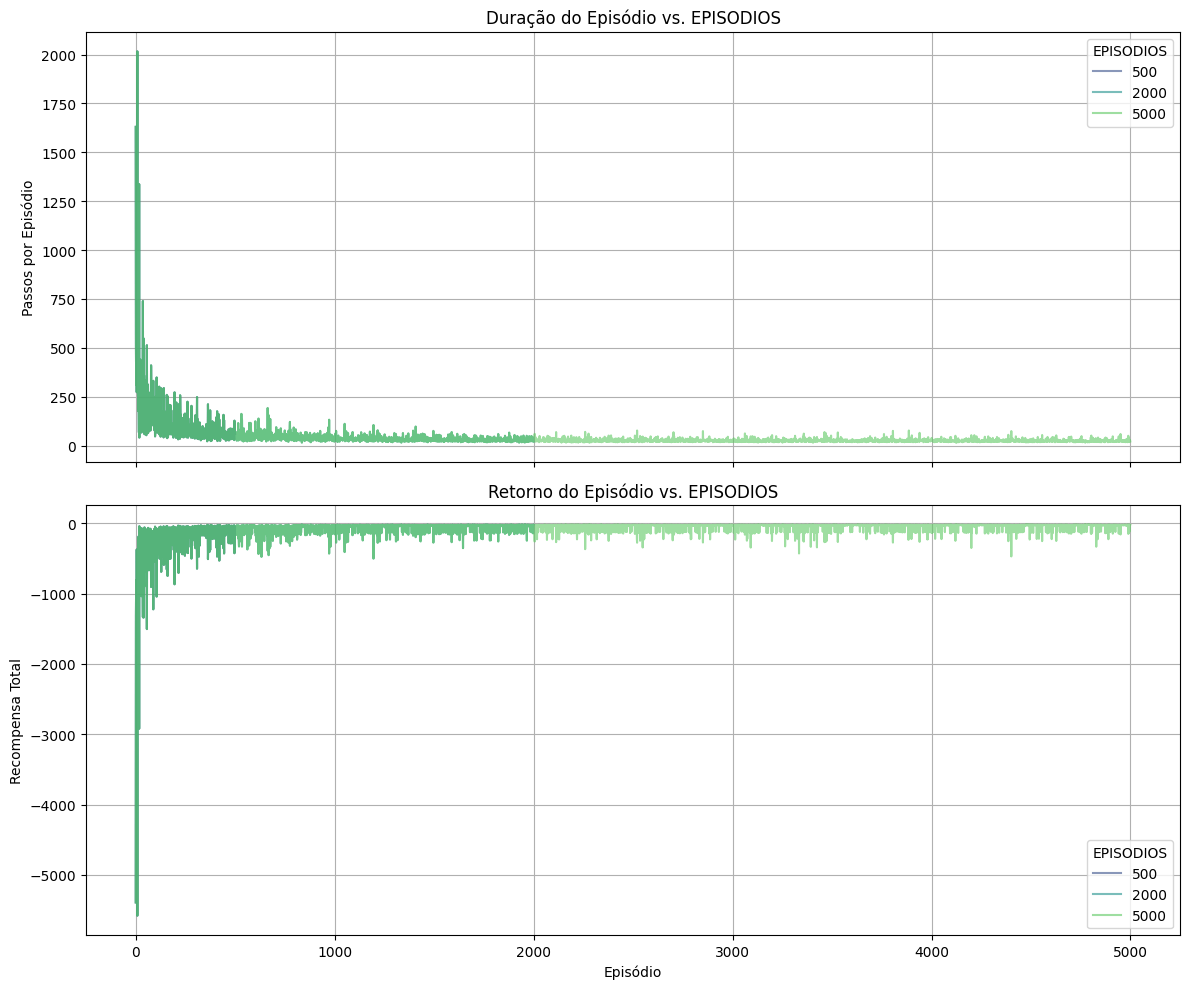


--- Trajetórias Gulosas (Variação de EPISODIOS) ---
Trajetória (gulosa) - EPISODIOS = 500


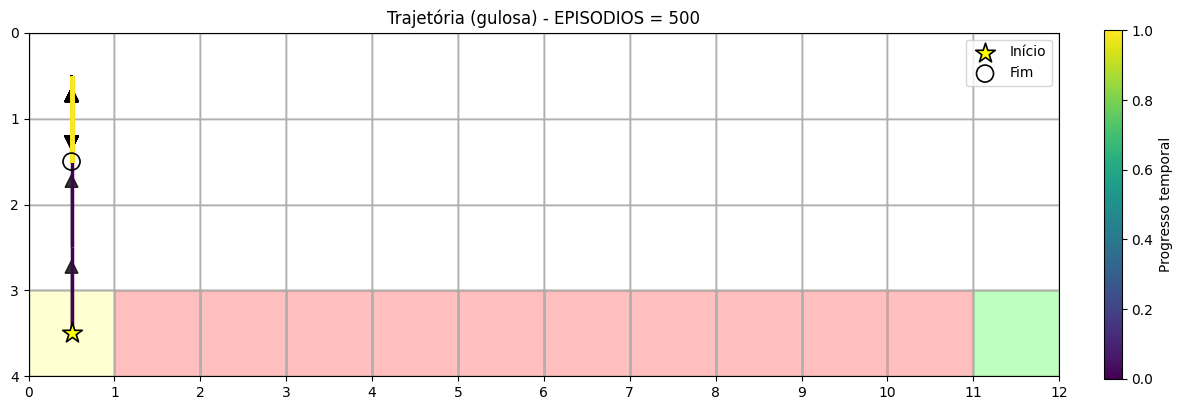

Trajetória (gulosa) - EPISODIOS = 2000


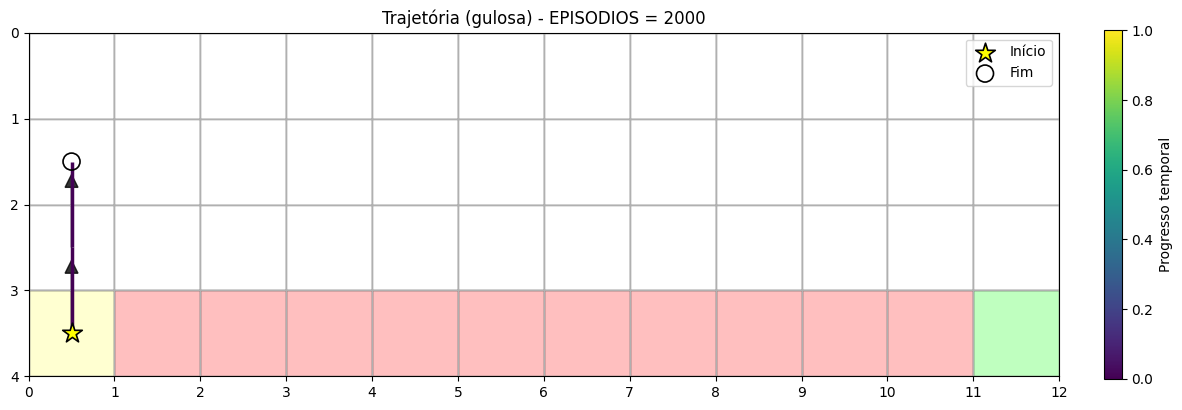

Trajetória (gulosa) - EPISODIOS = 5000


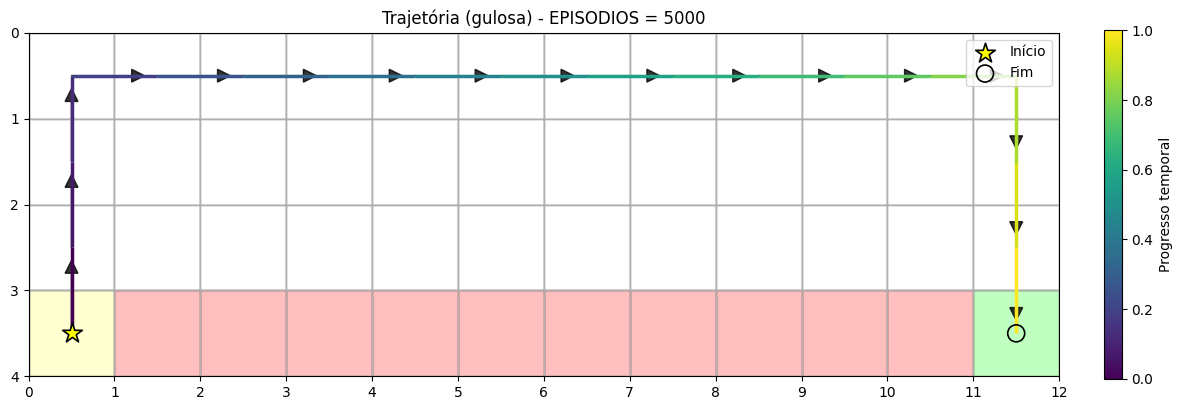

-------------------------------------------------


In [24]:
# 1. Variando EPISODIOS

# Parâmetros fixos para esta variação
params_fixos_eps = {
    'gamma': GAMMA,
    'epsilon': EPSILON,
    'alpha': ALPHA
    # 'N' (episódios) será variado
}

# Valores a testar
episodios_values = [500, 2000, 5000]

# Executar o experimento
df_T_eps, df_G_eps, pi_eps = executar_variacao_hiperparametro(
    env=env,
    param_name="EPISODIOS",
    param_values=episodios_values,
    fixed_params=params_fixos_eps,
    seed=SEED
)

# Plotar métricas
plotar_metricas_variacao(df_T_eps, df_G_eps, "EPISODIOS", palette='viridis')

# Plotar trajetórias
plotar_trajetorias_variacao(pi_eps, ambiente, "EPISODIOS")

### Variando o Alpha:

Variando o hiperparâmetro ALPHA com os valores: [0.001, 0.01, 0.1]
Parâmetros fixos: {'gamma': 0.9, 'epsilon': 0.3, 'N': 5000}

Executando SARSA com ALPHA = 0.001...


Episódios (SARSA):   0%|          | 0/5000 [00:00<?, ?it/s]


Executando SARSA com ALPHA = 0.01...


Episódios (SARSA):   0%|          | 0/5000 [00:00<?, ?it/s]


Executando SARSA com ALPHA = 0.1...


Episódios (SARSA):   0%|          | 0/5000 [00:00<?, ?it/s]


Execuções completas.


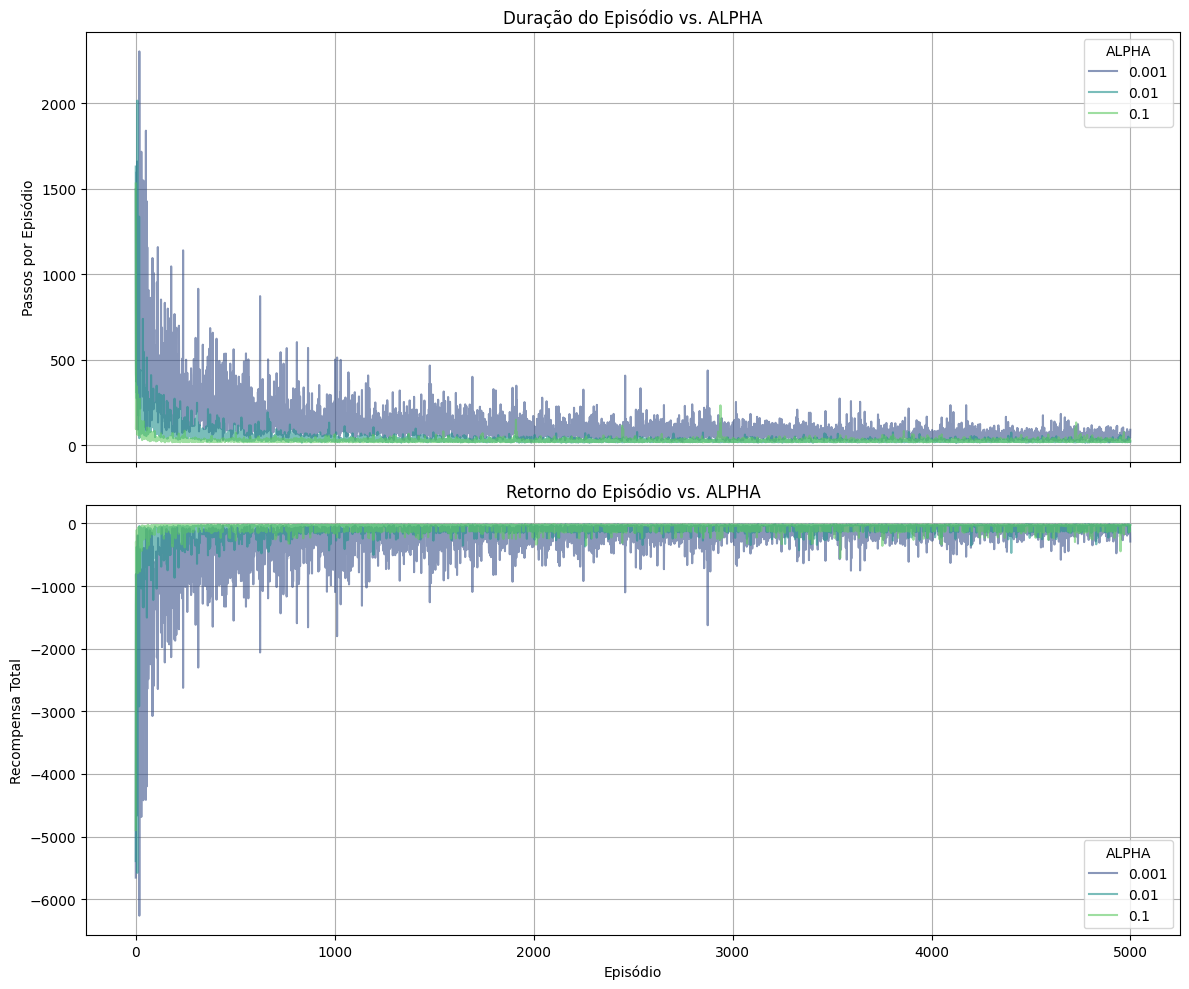


--- Trajetórias Gulosas (Variação de ALPHA) ---
Trajetória (gulosa) - ALPHA = 0.001


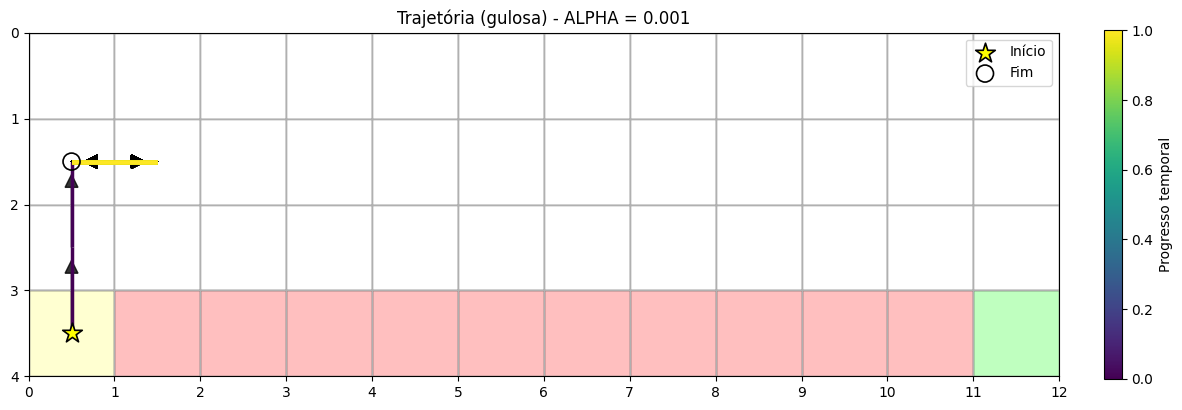

Trajetória (gulosa) - ALPHA = 0.01


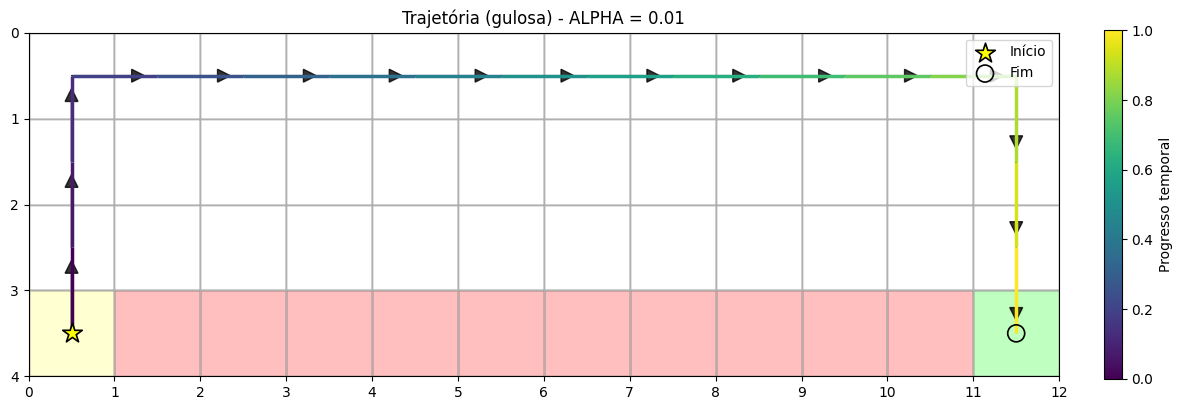

Trajetória (gulosa) - ALPHA = 0.1


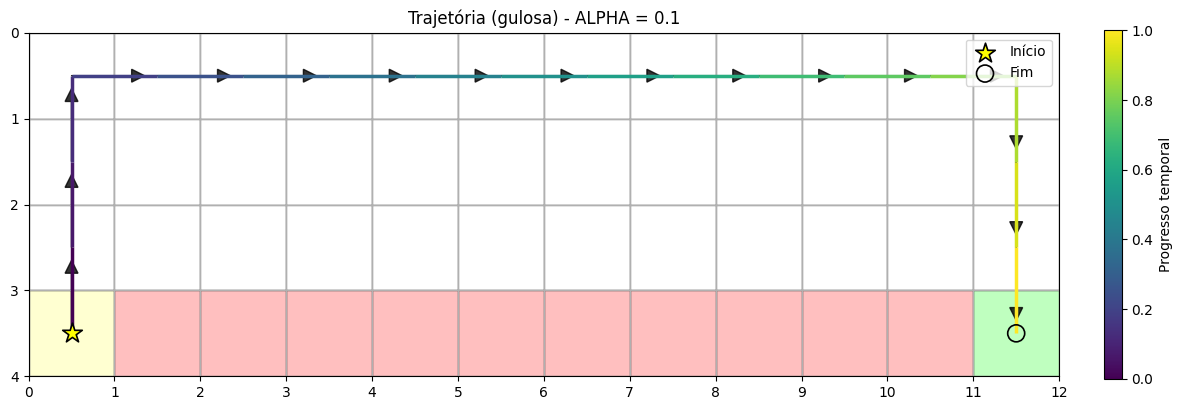

-------------------------------------------------


In [25]:
# 2. Variando ALPHA

# Parâmetros fixos para esta variação
params_fixos_alpha = {
    'gamma': GAMMA,
    'epsilon': EPSILON,
    'N': EPISODIOS # EPISODIOS agora é fixo
    # 'alpha' será variado
}

# Valores a testar
alpha_values = [0.001, 0.01, 0.1]

# Executar o experimento
df_T_alpha, df_G_alpha, pi_alpha = executar_variacao_hiperparametro(
    env=env,
    param_name="ALPHA",
    param_values=alpha_values,
    fixed_params=params_fixos_alpha,
    seed=SEED
)

# Plotar métricas
plotar_metricas_variacao(df_T_alpha, df_G_alpha, "ALPHA", palette='viridis')

# Plotar trajetórias
plotar_trajetorias_variacao(pi_alpha, ambiente, "ALPHA")

### Variando o Gamma:

Variando o hiperparâmetro GAMMA com os valores: [0.5, 0.7, 0.9]
Parâmetros fixos: {'alpha': 0.01, 'epsilon': 0.3, 'N': 5000}

Executando SARSA com GAMMA = 0.5...


Episódios (SARSA):   0%|          | 0/5000 [00:00<?, ?it/s]


Executando SARSA com GAMMA = 0.7...


Episódios (SARSA):   0%|          | 0/5000 [00:00<?, ?it/s]


Executando SARSA com GAMMA = 0.9...


Episódios (SARSA):   0%|          | 0/5000 [00:00<?, ?it/s]


Execuções completas.


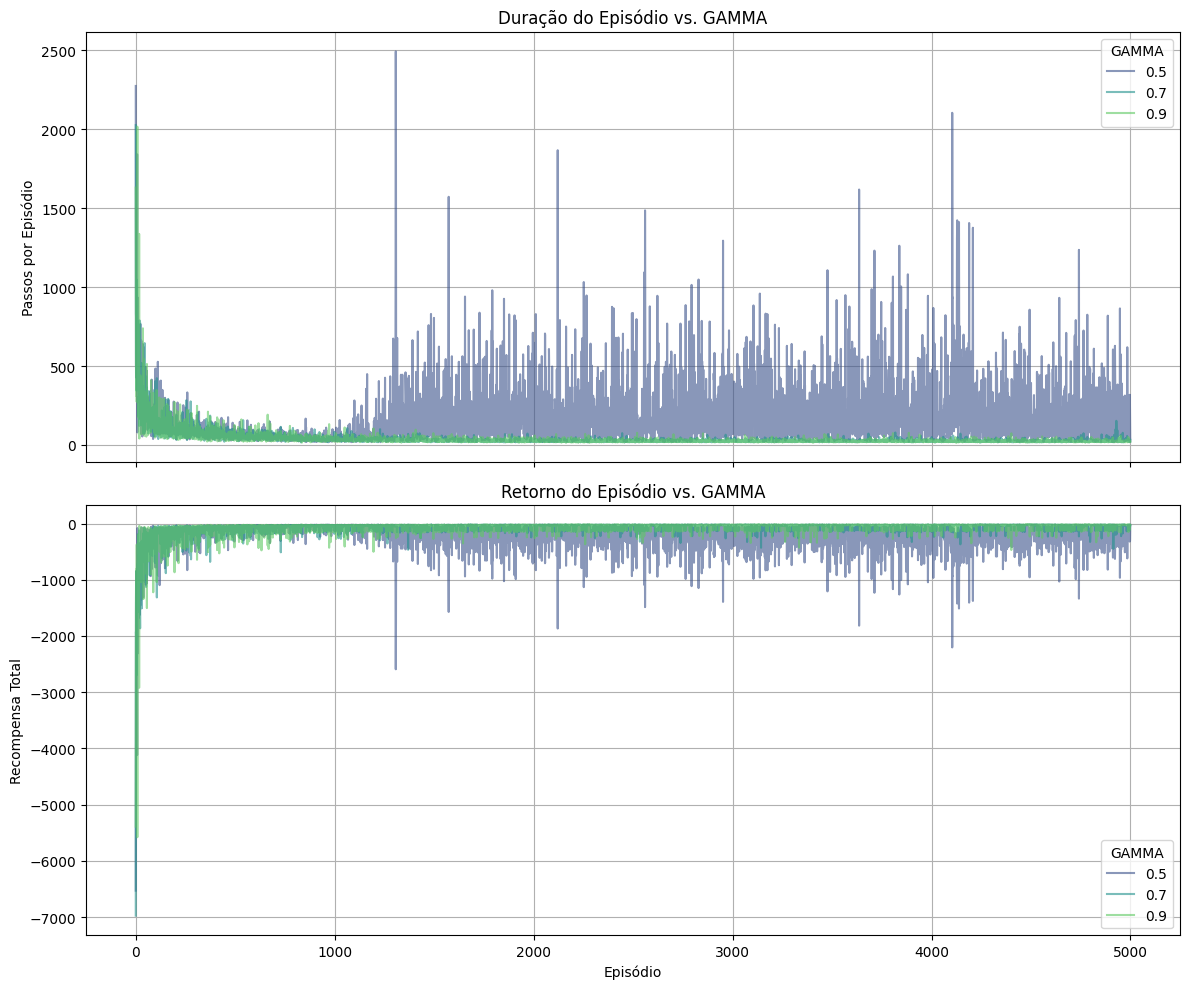


--- Trajetórias Gulosas (Variação de GAMMA) ---
Trajetória (gulosa) - GAMMA = 0.5


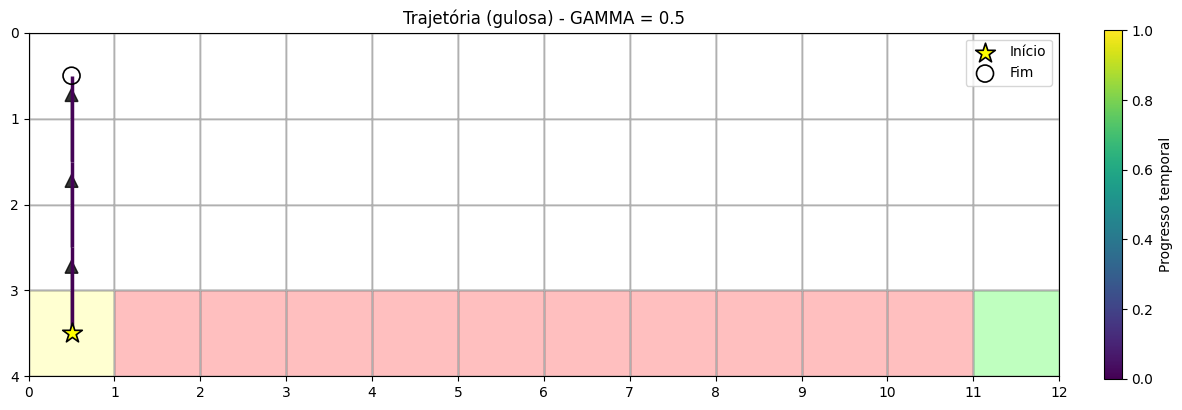

Trajetória (gulosa) - GAMMA = 0.7


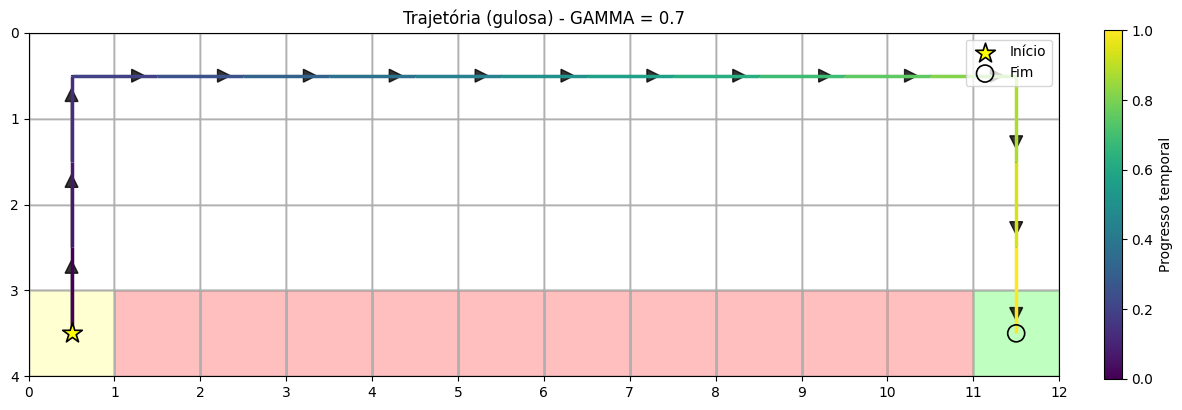

Trajetória (gulosa) - GAMMA = 0.9


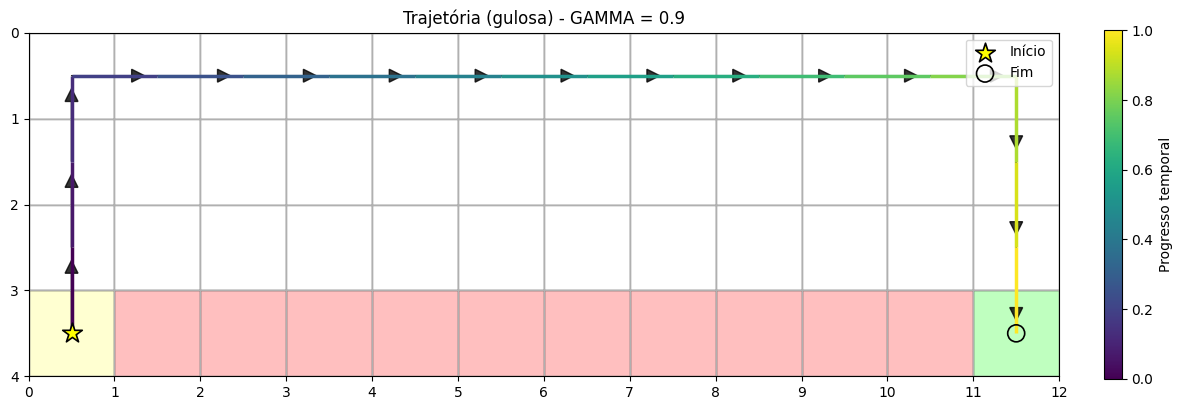

-------------------------------------------------


In [26]:
# 3. Variando GAMMA

# Parâmetros fixos para esta variação
params_fixos_gamma = {
    'alpha': ALPHA,
    'epsilon': EPSILON,
    'N': EPISODIOS
    # 'gamma' será variado
}

# Valores a testar
gamma_values = [0.5, 0.7, 0.9]

# Executar o experimento
df_T_gamma, df_G_gamma, pi_gamma = executar_variacao_hiperparametro(
    env=env,
    param_name="GAMMA",
    param_values=gamma_values,
    fixed_params=params_fixos_gamma,
    seed=SEED
)

# Plotar métricas
plotar_metricas_variacao(df_T_gamma, df_G_gamma, "GAMMA", palette='viridis')

# Plotar trajetórias
plotar_trajetorias_variacao(pi_gamma, ambiente, "GAMMA")

### Variando o Epsilon:

Variando o hiperparâmetro EPSILON com os valores: [0.05, 0.3, 0.6]
Parâmetros fixos: {'alpha': 0.01, 'gamma': 0.9, 'N': 5000}

Executando SARSA com EPSILON = 0.05...


Episódios (SARSA):   0%|          | 0/5000 [00:00<?, ?it/s]


Executando SARSA com EPSILON = 0.3...


Episódios (SARSA):   0%|          | 0/5000 [00:00<?, ?it/s]


Executando SARSA com EPSILON = 0.6...


Episódios (SARSA):   0%|          | 0/5000 [00:00<?, ?it/s]


Execuções completas.


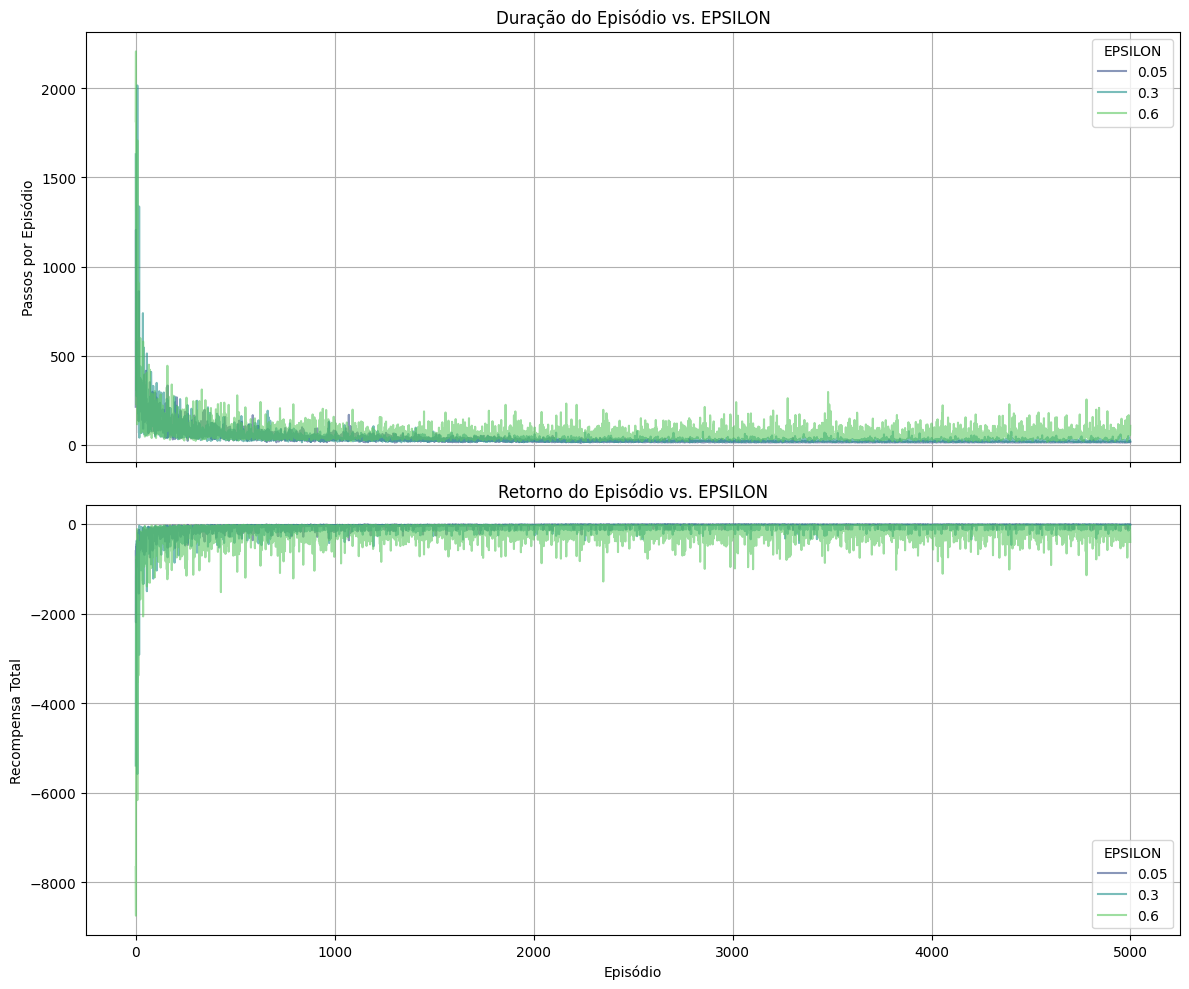


--- Trajetórias Gulosas (Variação de EPSILON) ---
Trajetória (gulosa) - EPSILON = 0.05


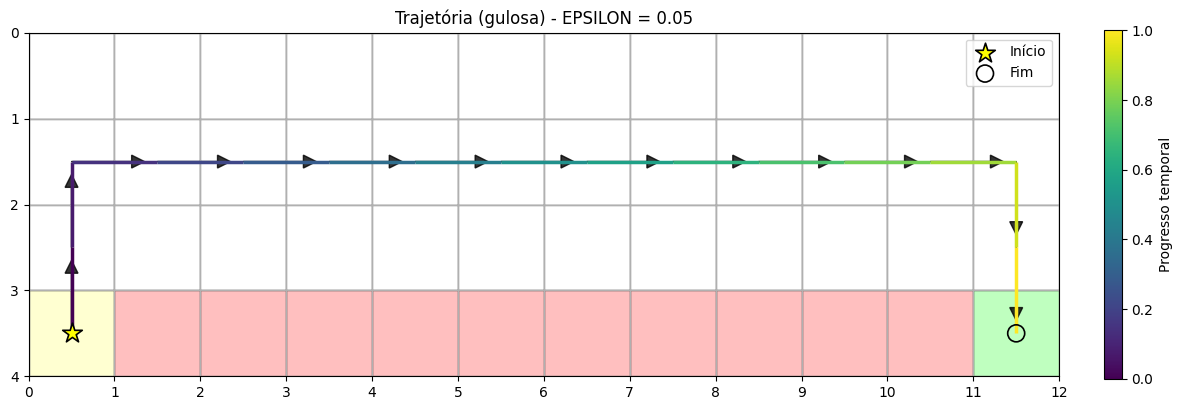

Trajetória (gulosa) - EPSILON = 0.3


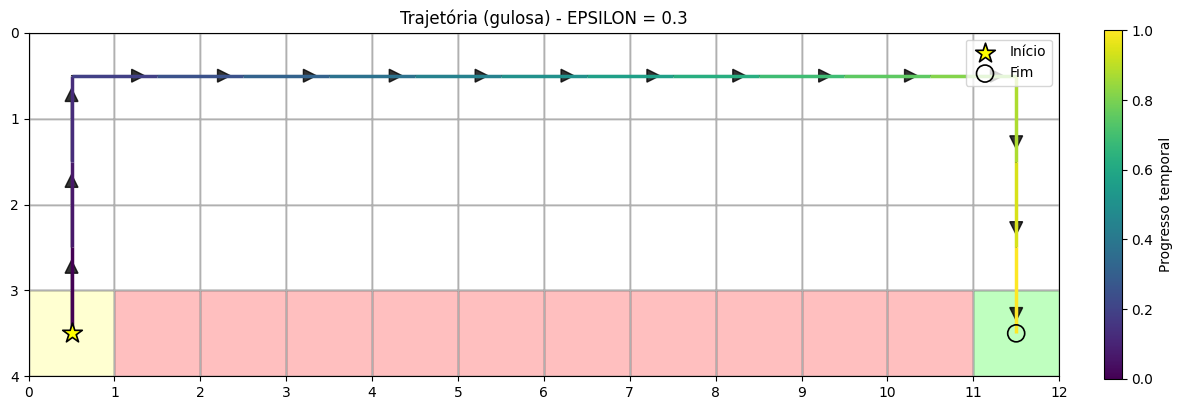

Trajetória (gulosa) - EPSILON = 0.6


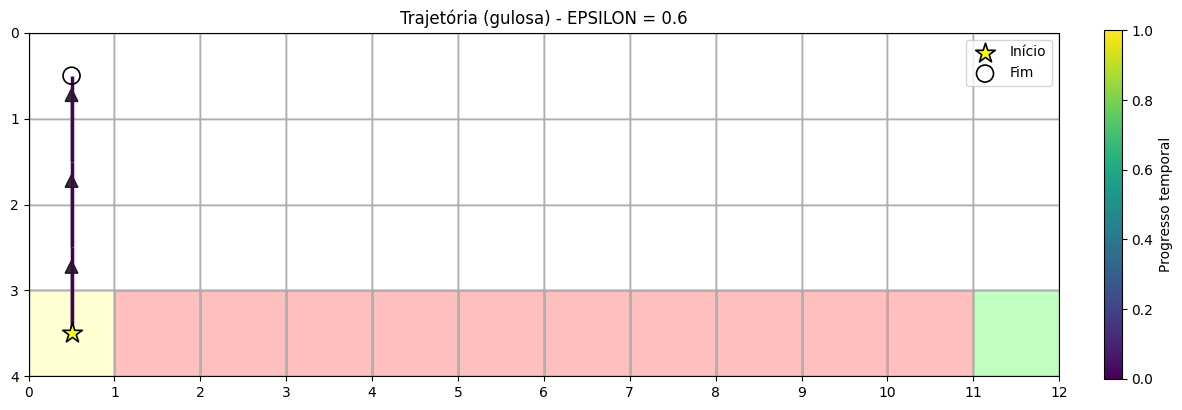

-------------------------------------------------


In [27]:
# 4. Variando EPSILON

# Parâmetros fixos para esta variação
params_fixos_epsilon = {
    'alpha': ALPHA,
    'gamma': GAMMA,
    'N': EPISODIOS
    # 'epsilon' será variado
}

# Valores a testar
epsilon_values = [0.05, 0.3, 0.6]

# Executar o experimento
df_T_epsilon, df_G_epsilon, pi_epsilon = executar_variacao_hiperparametro(
    env=env,
    param_name="EPSILON",
    param_values=epsilon_values,
    fixed_params=params_fixos_epsilon,
    seed=SEED
)

# Plotar métricas
plotar_metricas_variacao(df_T_epsilon, df_G_epsilon, "EPSILON", palette='viridis')

# Plotar trajetórias
plotar_trajetorias_variacao(pi_epsilon, ambiente, "EPSILON")